=== 城市降雨统计（Top 10）===
              mean    max    std  count
Location                               
Cairns        5.74  278.4  18.28   2988
Darwin        5.09  367.6  16.45   3193
CoffsHarbour  5.06  371.0  17.44   2953
GoldCoast     3.77  183.4  13.05   2980
Wollongong    3.59  192.0  11.90   2982
Williamtown   3.59  225.0  11.76   2553
Townsville    3.49  236.8  14.99   3033
NorahHead     3.39  126.4   9.39   2929
Sydney        3.32  119.4   9.89   3337
MountGinini   3.29  107.6   8.97   2907


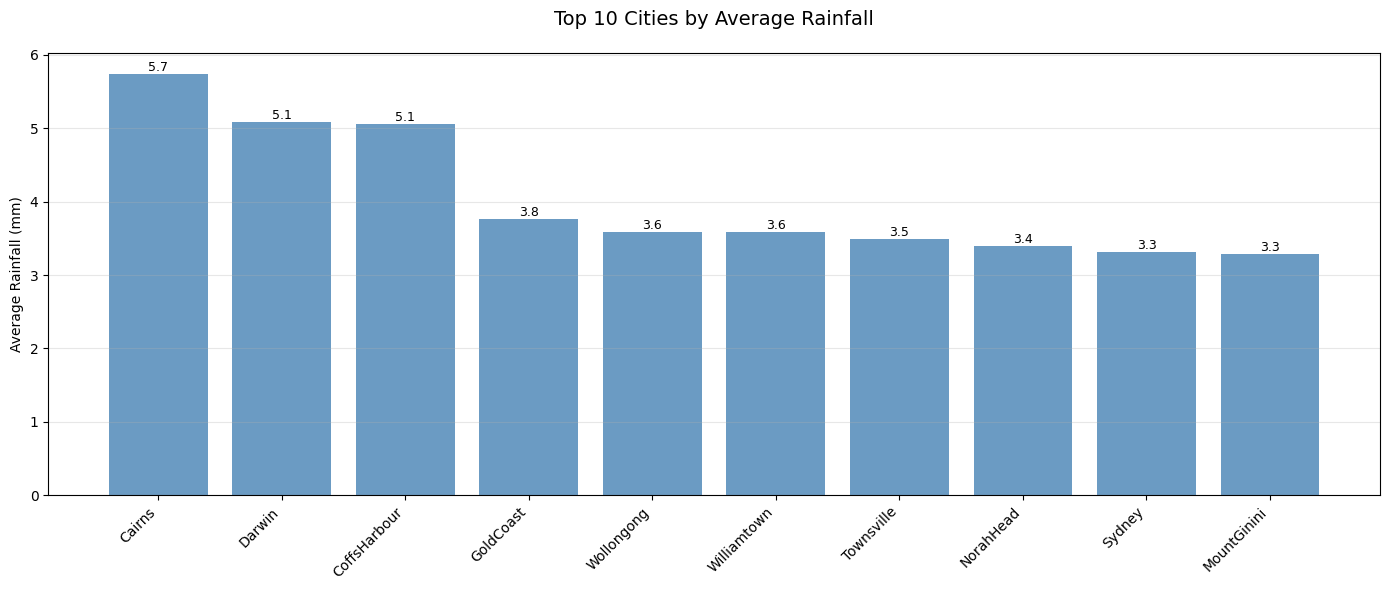

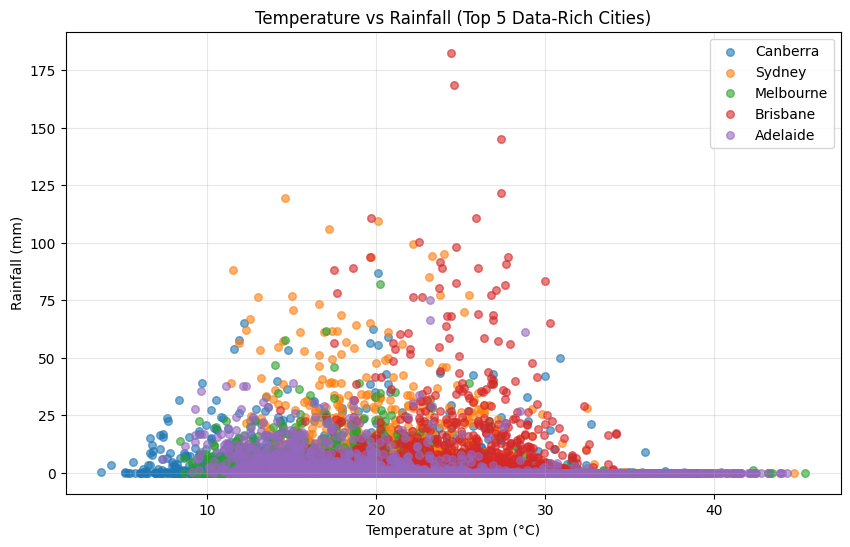


over。涉及城市数：49 个


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('weatherAUS.csv')

#按城市分组统计平均降雨量
city_rain_stats = data.groupby('Location')['Rainfall'].agg([
    'mean',      # 平均降雨量
    'max',       # 最大降雨量
    'std',       # 标准差（波动程度）
    'count'      # 数据条数
]).round(2)

# 按平均降雨量排序
city_rain_stats = city_rain_stats.sort_values('mean', ascending=False)

print("=== 城市降雨统计（Top 10）===")
print(city_rain_stats.head(10))

# 3. 可视化：平均降雨量Top10城市
plt.figure(figsize=(14, 6))
top10_cities = city_rain_stats.head(10)

# 画柱状图
bars = plt.bar(range(len(top10_cities)), top10_cities['mean'], color='steelblue', alpha=0.8)
plt.xticks(range(len(top10_cities)), top10_cities.index, rotation=45, ha='right')
plt.ylabel('Average Rainfall (mm)')
plt.title('Top 10 Cities by Average Rainfall', fontsize=14, pad=20)
plt.grid(axis='y', alpha=0.3)

# 在柱子上添加数值标签
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('top10_city_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. 高级分析：降雨量与温度的关系（散点图）
plt.figure(figsize=(10, 6))
# 取数据量最多的5个城市对比
top5_cities = data['Location'].value_counts().head(5).index

for city in top5_cities:
    city_data = data[data['Location'] == city]
    plt.scatter(city_data['Temp3pm'], city_data['Rainfall'],
                alpha=0.6, label=city, s=30)

plt.xlabel('Temperature at 3pm (°C)')
plt.ylabel('Rainfall (mm)')
plt.title('Temperature vs Rainfall (Top 5 Data-Rich Cities)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('temp_vs_rainfall_scatter.png', dpi=150)
plt.show()

print(f"\nover。涉及城市数：{len(city_rain_stats)} 个")